# Fase 5 — Análisis de Balance

Síntesis de todas las fases anteriores para generar recomendaciones de balanceo del juego.

**Entradas:**
- `data/processed/sessions.parquet`, `levels.parquet`, `rooms.parquet`
- `data/exports/statistical_results.csv`, `ml_predictions.csv`, `nlp_results.csv`, `eda_hallazgos.csv`

**Salidas:**
- `data/exports/balance_index.csv` — Puntuación Global por elemento
- `data/exports/balance_recommendations.csv` — tabla de recomendaciones priorizadas
- Figuras en `reports/figures/`: fig7_1 a fig7_4
- `reports/balance_report.html` — informe HTML

## Bloque 1 — Carga de datos y exports previos

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import seaborn as sns
from pathlib import Path

from visualization import PALETTE_ELEM
from analysis import (
    compute_killedwith_efficiency,
    compute_balance_index,
    element_level_matrix,
    top_abandoned_rooms,
    generate_recommendations,
)

PROCESSED = Path('../data/processed')
EXPORTS   = Path('../data/exports')
FIGURES   = Path('../reports/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [2]:
# Datos procesados
df_sessions_all = pd.read_parquet(PROCESSED / 'sessions.parquet')
df_levels_all   = pd.read_parquet(PROCESSED / 'levels.parquet')
df_rooms_all    = pd.read_parquet(PROCESSED / 'rooms.parquet')

# Filtrar sesiones limpias (WebGL, no sospechosas) — igual que el dashboard
df_sessions = df_sessions_all[~df_sessions_all['is_suspicious']].copy()
df_levels   = df_levels_all[df_levels_all['sessionId'].isin(df_sessions['sessionId'])].copy()
df_rooms    = df_rooms_all[df_rooms_all['sessionId'].isin(df_sessions['sessionId'])].copy()

# Exports de fases anteriores
statistical_results = pd.read_csv(EXPORTS / 'statistical_results.csv')
ml_predictions      = pd.read_csv(EXPORTS / 'ml_predictions.csv')
player_clusters     = pd.read_csv(EXPORTS / 'player_clusters.csv')
nlp_results         = pd.read_csv(EXPORTS / 'nlp_results.csv')
eda_hallazgos       = pd.read_csv(EXPORTS / 'eda_hallazgos.csv')

print(f'Sesiones totales: {len(df_sessions_all)} | Limpias (WebGL, no sospechosas): {len(df_sessions)}')
print(f'Niveles: {len(df_levels)} | Salas: {len(df_rooms)}')
print(f'Elementos: {df_sessions["playerElement"].value_counts().to_dict()}')

Sesiones totales: 53 | Limpias (WebGL, no sospechosas): 35
Niveles: 88 | Salas: 478
Elementos: {'Fire': 11, 'Water': 9, 'Wind': 8, 'Earth': 7}


## Bloque 2 — Heatmap elemento × nivel (TFM-29)

Visualiza la distribución de dificultad (muertes, tasa de completado, daño) por elemento y nivel.

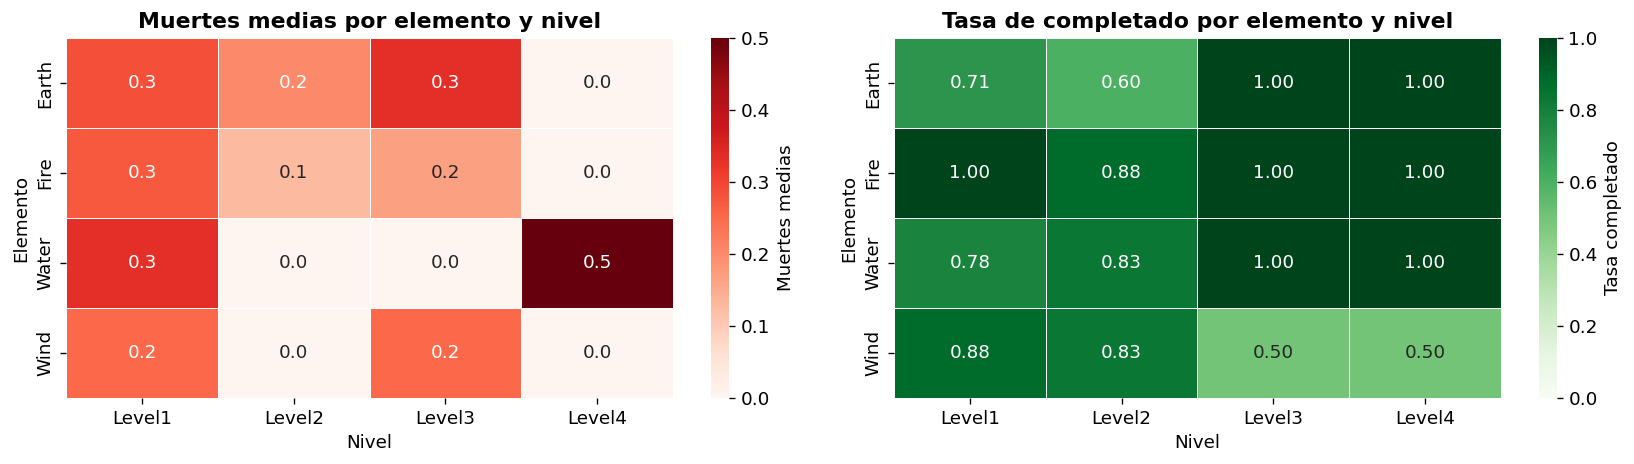

fig7_1_heatmap_elemento_nivel.png guardada.


In [3]:
# Matriz elemento × nivel — tasa de muertes
matrix_death = element_level_matrix(df_sessions, df_levels, df_rooms, metric='death_rate')
matrix_comp  = element_level_matrix(df_sessions, df_levels, df_rooms, metric='completion_rate')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Muertes medias
sns.heatmap(
    matrix_death,
    ax=axes[0],
    cmap='Reds',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': 'Muertes medias'},
)
axes[0].set_title('Muertes medias por elemento y nivel', fontweight='bold')
axes[0].set_xlabel('Nivel')
axes[0].set_ylabel('Elemento')

# Tasa de completado
sns.heatmap(
    matrix_comp,
    ax=axes[1],
    cmap='Greens',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Tasa completado'},
    vmin=0, vmax=1,
)
axes[1].set_title('Tasa de completado por elemento y nivel', fontweight='bold')
axes[1].set_xlabel('Nivel')
axes[1].set_ylabel('Elemento')

plt.tight_layout()
fig.savefig(FIGURES / 'fig7_1_heatmap_elemento_nivel.png', bbox_inches='tight')
plt.show()
print('fig7_1_heatmap_elemento_nivel.png guardada.')

**Conclusión bloque 2:** El heatmap permite identificar niveles problemáticos para elementos específicos. Celdas en rojo oscuro (muchas muertes) o verde claro (baja tasa de completado) indican desequilibrios que merecen revisión.

## Bloque 3 — Salas con mayor score de abandono (TFM-17)

In [4]:
# Top 10 salas por score de abandono
df_abandon = top_abandoned_rooms(df_rooms, df_sessions, n=10)

print('Top 10 salas con mayor score de abandono:')
display(df_abandon[['levelId', 'roomId', 'deaths_mean', 'damage_mean', 'n_visits', 'abandonment_score']]
        .style.background_gradient(subset='abandonment_score', cmap='Reds')
        .format({'deaths_mean': '{:.2f}', 'damage_mean': '{:.1f}', 'abandonment_score': '{:.3f}'}))

Top 10 salas con mayor score de abandono:


,levelId,roomId,deaths_mean,damage_mean,n_visits,abandonment_score
0,Level1,Room_04,0.26,140.2,34,1.000
1,Level1,Room_Boss,0.07,112.8,30,0.528
2,Level2,Room_Boss,0.10,94.2,20,0.525
3,Level3,Room_04,0.13,60.4,15,0.467
4,Level3,Room_05,0.07,64.9,14,0.366
5,Level4,Room_02,0.10,35.1,10,0.314
6,Level3,Room_02,0.06,46.9,16,0.285
7,Level3,Room_Boss,0.00,78.9,14,0.281
8,Level4,Room_Boss,0.00,78.4,10,0.280
9,Level1,Room_03,0.00,75.7,34,0.270


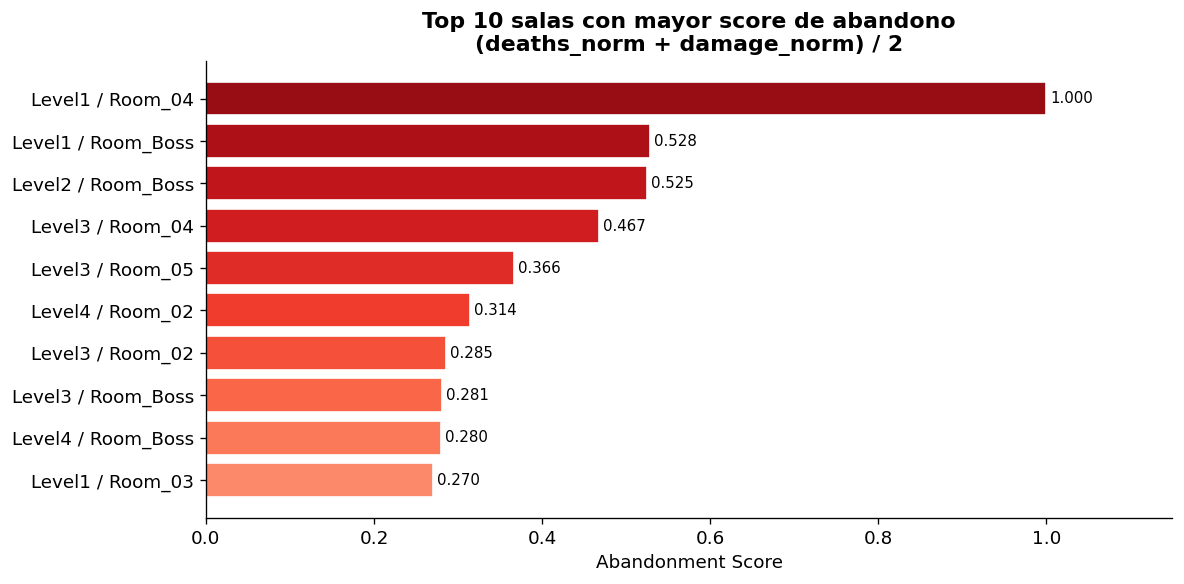

fig7_2_salas_abandono.png guardada.


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

# Etiqueta nivel+sala para el eje Y
df_abandon['sala_label'] = df_abandon['levelId'] + ' / ' + df_abandon['roomId']

bars = ax.barh(
    df_abandon['sala_label'],
    df_abandon['abandonment_score'],
    color=plt.cm.Reds(np.linspace(0.4, 0.9, len(df_abandon)))[::-1],
    edgecolor='white',
)

# Etiquetas de valor
for bar, score in zip(bars, df_abandon['abandonment_score']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{score:.3f}', va='center', fontsize=9)

ax.set_xlabel('Abandonment Score')
ax.set_title('Top 10 salas con mayor score de abandono\n(deaths_norm + damage_norm) / 2', fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, df_abandon['abandonment_score'].max() * 1.15)
sns.despine(ax=ax)

plt.tight_layout()
fig.savefig(FIGURES / 'fig7_2_salas_abandono.png', bbox_inches='tight')
plt.show()
print('fig7_2_salas_abandono.png guardada.')

**Conclusión bloque 3:** Las salas con mayor score de abandono combinan alto daño recibido y muchas muertes. Estas salas son candidatas prioritarias para ajuste de dificultad (reducir HP de enemigos, añadir cobertura, etc.).

## Bloque 4 — Puntuación Global por elemento (TFM-43, TFM-44)

In [6]:
# Calcular Puntuación Global usando killedWith_* como fuente de eficiencia real
balance_index_raw = compute_balance_index(df_sessions, nlp_results, df_rooms=df_rooms)

# --- Mejora N: ponderación por fiabilidad de cada componente ---
# win_rate: n=30 sesiones → fiable (peso 0.5)
# kills_efficiency: noisy para Wind (n=4, 0 kills) → peso moderado (0.3)
# sentiment: solo n=4 comentarios reales → poco fiable (peso 0.2)
n_sessions_by_elem = df_sessions.groupby('playerElement').size().to_dict()

def weighted_balance_index(row, n_sessions):
    n = n_sessions.get(row['playerElement'], 1)
    w_wr   = 0.5   # win_rate es el más representativo
    w_keff = 0.3   # kills_efficiency moderado
    w_sent = 0.2   # sentiment basado en muy pocos comentarios
    bi = (w_wr * row['win_rate'] +
          w_keff * row['kills_efficiency'] +
          w_sent * row['sentiment_score'])
    return round(bi, 4)

balance_index = balance_index_raw.copy()
balance_index['balance_index_raw'] = balance_index_raw['balance_index']
balance_index['balance_index'] = balance_index.apply(
    lambda r: weighted_balance_index(r, n_sessions_by_elem), axis=1
)
balance_index['n_sessions'] = balance_index['playerElement'].map(n_sessions_by_elem)

# --- Mejora L: marcar Wind como datos insuficientes ---
MIN_SESSIONS_FIABLE = 10
balance_index['datos_suficientes'] = balance_index['n_sessions'] >= MIN_SESSIONS_FIABLE
balance_index['nota'] = balance_index.apply(
    lambda r: f'n={r.n_sessions} — INSUFICIENTE (mín {MIN_SESSIONS_FIABLE})' 
              if not r['datos_suficientes'] else f'n={r.n_sessions}',
    axis=1
)

print('Puntuación Global por elemento (ponderado + validez de muestra):')
print()
display(balance_index[['playerElement','n_sessions','win_rate','kills_efficiency',
                        'sentiment_score','balance_index_raw','balance_index',
                        'datos_suficientes','nota']])
print()
print('Nota: balance_index_raw = fórmula multiplicativa original (win_rate × sent × (1+keff))')
print('      balance_index      = fórmula ponderada (0.5·wr + 0.3·keff + 0.2·sent)')
print()
print('⚠ Elementos con n < 10 sesiones: resultados NO son estadísticamente fiables.')
for _, r in balance_index[~balance_index['datos_suficientes']].iterrows():
    print(f'  {r.playerElement}: {r.nota}')

Puntuación Global por elemento (ponderado + validez de muestra):



D:\DataScience\Proyecto-TFM-HackAndSlash\notebooks\..\src\analysis.py:80: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kpm = kw_eff.groupby('element').apply(


,playerElement,n_sessions,win_rate,kills_efficiency,sentiment_score,balance_index_raw,balance_index,datos_suficientes,nota
0,Fire,11,0.363636,1.000000,0.50,0.3636,0.5818,True,n=11
1,Earth,7,0.428571,0.653611,0.50,0.3543,0.5104,False,n=7 — INSUFICIENTE (mín 10)
2,Water,9,0.222222,0.000000,0.50,0.1111,0.2111,False,n=9 — INSUFICIENTE (mín 10)
3,Wind,8,0.125000,0.131972,0.25,0.0354,0.1521,False,n=8 — INSUFICIENTE (mín 10)



Nota: balance_index_raw = fórmula multiplicativa original (win_rate × sent × (1+keff))
      balance_index      = fórmula ponderada (0.5·wr + 0.3·keff + 0.2·sent)

⚠ Elementos con n < 10 sesiones: resultados NO son estadísticamente fiables.
  Earth: n=7 — INSUFICIENTE (mín 10)
  Water: n=9 — INSUFICIENTE (mín 10)
  Wind: n=8 — INSUFICIENTE (mín 10)


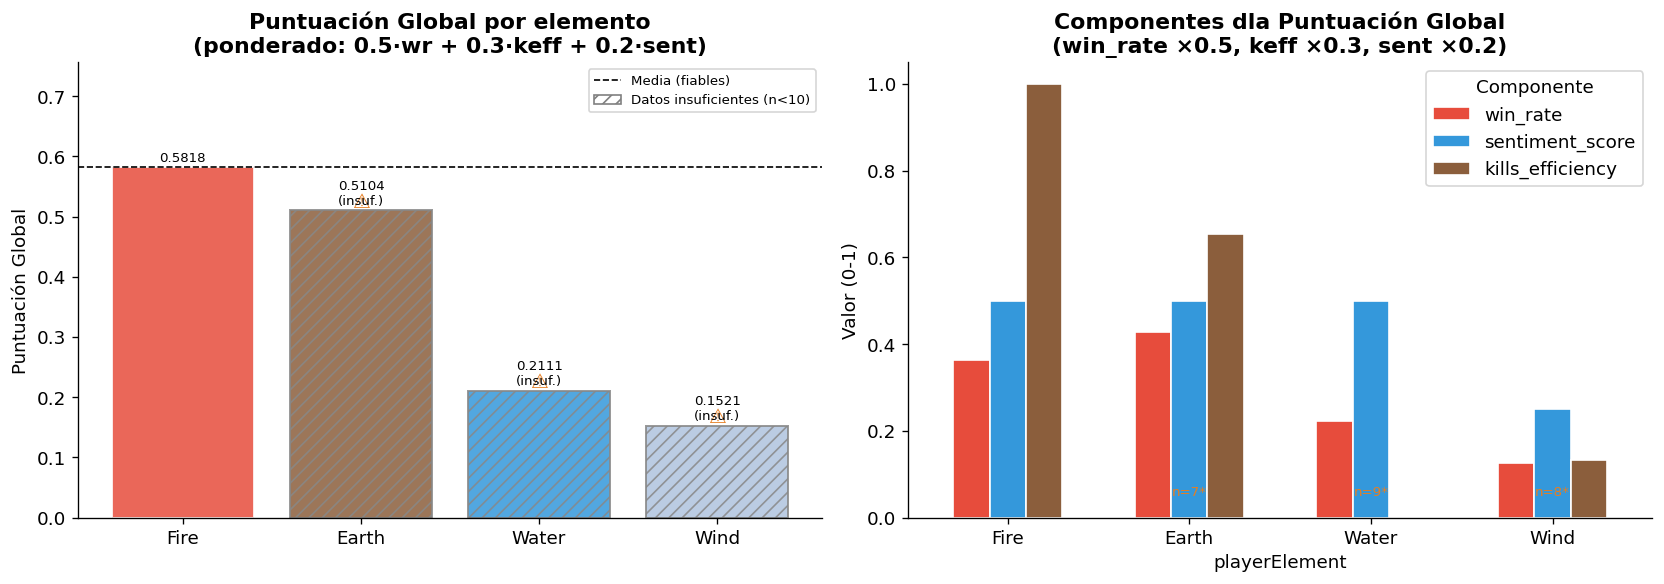

fig7_3_balance_index.png guardada.

Nota: elementos con /// tienen n < 10 sesiones — Puntuación Global orientativa.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Barplot Puntuación Global (ponderado) con marcas de fiabilidad ----
colors = [PALETTE_ELEM.get(e, '#999999') for e in balance_index['playerElement']]
bars = axes[0].bar(balance_index['playerElement'], balance_index['balance_index'],
                   color=colors, edgecolor='white', linewidth=1.2, alpha=0.85)

# Hatch para elementos con datos insuficientes
for bar, (_, row) in zip(bars, balance_index.iterrows()):
    if not row['datos_suficientes']:
        bar.set_hatch('///')
        bar.set_edgecolor('#888888')
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     '⚠', ha='center', fontsize=12, color='#e67e22')

axes[0].axhline(balance_index[balance_index['datos_suficientes']]['balance_index'].mean(),
                color='black', linestyle='--', linewidth=1,
                label='Media (sólo elementos fiables)')
for i, (_, row) in enumerate(balance_index.iterrows()):
    label = f"{row['balance_index']:.4f}"
    if not row['datos_suficientes']:
        label += '\n(insuf.)'
    axes[0].text(i, row['balance_index'] + 0.01, label, ha='center', fontsize=8)

axes[0].set_title('Puntuación Global por elemento\n(ponderado: 0.5·wr + 0.3·keff + 0.2·sent)', fontweight='bold')
axes[0].set_ylabel('Puntuación Global')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, balance_index['balance_index'].max() * 1.3)
sns.despine(ax=axes[0])

# Parche de leyenda para hatch
from matplotlib.patches import Patch
hatch_patch = Patch(facecolor='white', edgecolor='grey', hatch='///', label='Datos insuficientes (n<10)')
axes[0].legend(handles=[
    plt.Line2D([0],[0], color='black', linestyle='--', linewidth=1, label='Media (fiables)'),
    hatch_patch
], fontsize=8)

# ---- Barras apiladas componentes ----
components = balance_index.set_index('playerElement')[['win_rate', 'sentiment_score', 'kills_efficiency']]
components.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#3498db', '#8B5E3C'],
                edgecolor='white', width=0.6)
axes[1].set_title('Componentes dla Puntuación Global\n(win_rate ×0.5, keff ×0.3, sent ×0.2)', fontweight='bold')
axes[1].set_ylabel('Valor (0-1)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Componente', loc='upper right')

# Marcar los insuficientes con asterisco
for i, (_, row) in enumerate(balance_index.iterrows()):
    if not row['datos_suficientes']:
        axes[1].text(i, 0.05, f'n={row.n_sessions}*', ha='center', fontsize=8, color='#e67e22')

sns.despine(ax=axes[1])

plt.tight_layout()
fig.savefig(FIGURES / 'fig7_3_balance_index.png', bbox_inches='tight')
plt.show()
print('fig7_3_balance_index.png guardada.')
print()
print('Nota: elementos con /// tienen n < 10 sesiones — Puntuación Global orientativa.')

**Conclusión bloque 4:** La Puntuación Global refleja el rendimiento combinado de cada elemento. Un valor alto indica buena combinación de win_rate, sentimiento positivo y eficiencia de kills. Diferencias grandes entre elementos sugieren desequilibrio que debe investigarse.

## Bloque 5 — Perfil por elemento: fortalezas y debilidades (TFM-30)

In [8]:
# Eficiencia real de hechizos via killedWith_* (fuente más fiable que cast ratio)
spell_eff = compute_killedwith_efficiency(df_rooms, df_sessions)

print('Eficiencia real de hechizos por elemento (kills reales / cast):')
display(spell_eff.pivot(index='element', columns='spell', values='efficiency').round(4))
print()
print('Kills reales por hechizo y elemento:')
display(spell_eff.pivot(index='element', columns='spell', values='kills'))

Eficiencia real de hechizos por elemento (kills reales / cast):


spell,AOE,Beam,Blast,Projectile
element,,,,
Earth,0.1481,0.7419,0.3850,0.1565
Fire,0.0000,2.1149,0.4402,0.1605
Water,0.0556,0.9910,0.1820,0.1198
Wind,0.1458,0.9074,0.2624,0.1167



Kills reales por hechizo y elemento:


spell,AOE,Beam,Blast,Projectile
element,,,,
Earth,8,69,154,151
Fire,0,184,206,253
Water,2,110,91,219
Wind,7,98,95,171


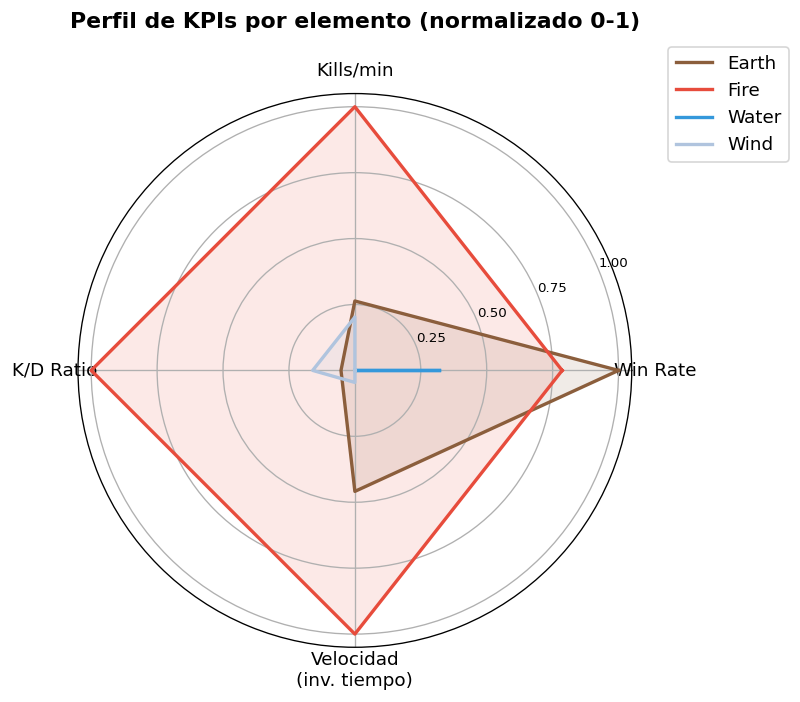

fig7_4_perfiles_elemento.png guardada.


In [9]:
# KPIs por elemento para perfil radar (barplot múltiple como alternativa)
kpis = df_sessions.groupby('playerElement').agg(
    win_rate       =('isVictory', 'mean'),
    kills_per_min  =('kills_per_min', 'mean'),
    kd_ratio       =('kd_ratio', 'mean'),
    time_per_level =('time_per_level', 'mean'),
    n_sessions     =('sessionId', 'count'),
).reset_index()

# Normalizar para poder comparar en la misma escala [0,1]
for col in ['win_rate', 'kills_per_min', 'kd_ratio', 'time_per_level']:
    col_min, col_max = kpis[col].min(), kpis[col].max()
    kpis[f'{col}_norm'] = (kpis[col] - col_min) / (col_max - col_min) if col_max > col_min else 0.5

# Invertir time_per_level (más tiempo = peor eficiencia)
kpis['time_per_level_norm'] = 1 - kpis['time_per_level_norm']

# ---- Radar chart manual con matplotlib ----
kpi_labels  = ['Win Rate', 'Kills/min', 'K/D Ratio', 'Velocidad\n(inv. tiempo)']
norm_cols   = ['win_rate_norm', 'kills_per_min_norm', 'kd_ratio_norm', 'time_per_level_norm']
N           = len(kpi_labels)
angles      = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles     += angles[:1]  # cerrar polígono

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, row in kpis.iterrows():
    values = [row[c] for c in norm_cols]
    values += values[:1]
    color  = PALETTE_ELEM.get(row['playerElement'], '#999999')
    ax.plot(angles, values, color=color, linewidth=2, label=row['playerElement'])
    ax.fill(angles, values, color=color, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(kpi_labels, size=11)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], size=8)
ax.set_title('Perfil de KPIs por elemento (normalizado 0-1)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
fig.savefig(FIGURES / 'fig7_4_perfiles_elemento.png', bbox_inches='tight')
plt.show()
print('fig7_4_perfiles_elemento.png guardada.')

**Conclusión bloque 5:** El radar permite identificar de un vistazo las fortalezas y debilidades de cada elemento. Un elemento desequilibrado se verá con un área muy diferente al resto. Idealmente todos los elementos deben tener perfiles similares.

## Bloque 6 — Tabla de recomendaciones (TFM-31, TFM-32)

## Bloque 5b — Mejora M: Funnel por elemento en Level1

=== Funnel Level1 por elemento ===
playerElement  sesiones_en_lv1  completaron_lv1  pct_completaron  total_sesiones  pct_llegan_a_lv1
        Earth                7                5             71.4               7             100.0
         Fire               11               11            100.0              11             100.0
        Water                9                7             77.8               9             100.0
         Wind                8                7             87.5               8             100.0



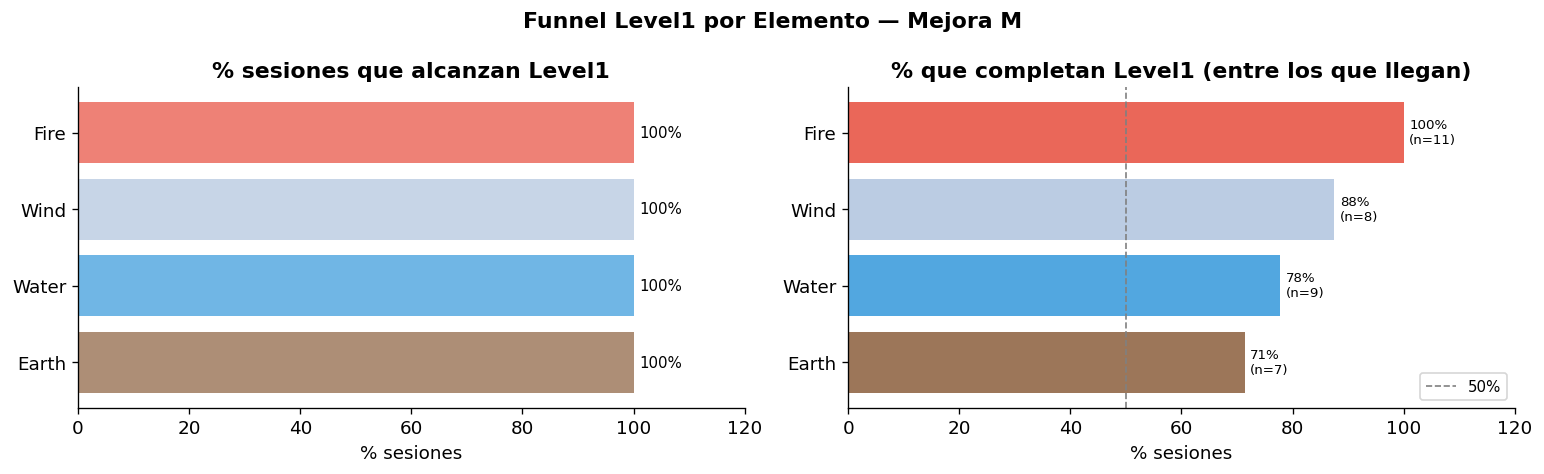

fig7_5_funnel_level1.png guardada.


In [10]:
# --- Mejora M: funnel Level1 cuantificado por elemento ---
# Sesiones que completaron Level1 = tienen registro en df_levels con levelId='Level1' y incomplete=False
lv1 = df_levels[df_levels['levelId'] == 'Level1'].merge(
    df_sessions[['sessionId', 'playerElement']], on='sessionId', how='left'
)
lv1['completed'] = ~lv1['incomplete']

funnel = lv1.groupby('playerElement').agg(
    sesiones_en_lv1=('sessionId', 'count'),
    completaron_lv1=('completed', 'sum'),
).reset_index()
funnel['pct_completaron'] = (funnel['completaron_lv1'] / funnel['sesiones_en_lv1'] * 100).round(1)

# Sesiones totales por elemento
total_sessions = df_sessions.groupby('playerElement').size().rename('total_sesiones').reset_index()
funnel = funnel.merge(total_sessions, on='playerElement', how='left')
funnel['pct_llegan_a_lv1'] = (funnel['sesiones_en_lv1'] / funnel['total_sesiones'] * 100).round(1)

print('=== Funnel Level1 por elemento ===')
print(funnel.to_string(index=False))
print()

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

elem_order_f = funnel.sort_values('pct_completaron', ascending=True)['playerElement']
colors_f = [PALETTE_ELEM.get(e, '#888') for e in elem_order_f]

# % que llegan a Level1
axes[0].barh(funnel.set_index('playerElement').loc[elem_order_f, 'pct_llegan_a_lv1'].index,
             funnel.set_index('playerElement').loc[elem_order_f, 'pct_llegan_a_lv1'].values,
             color=colors_f, alpha=0.7, label='% llegan a Level1')
axes[0].set_xlabel('% sesiones')
axes[0].set_title('% sesiones que alcanzan Level1', fontweight='bold')
axes[0].set_xlim(0, 120)
for i, (elem, row) in enumerate(funnel.set_index('playerElement').loc[elem_order_f].iterrows()):
    axes[0].text(row['pct_llegan_a_lv1'] + 1, i, f"{row['pct_llegan_a_lv1']:.0f}%", va='center', fontsize=9)

# % que completan Level1
axes[1].barh(funnel.set_index('playerElement').loc[elem_order_f, 'pct_completaron'].index,
             funnel.set_index('playerElement').loc[elem_order_f, 'pct_completaron'].values,
             color=colors_f, alpha=0.85)
axes[1].axvline(50, color='gray', linestyle='--', linewidth=1, label='50%')
axes[1].set_xlabel('% sesiones')
axes[1].set_title('% que completan Level1 (entre los que llegan)', fontweight='bold')
axes[1].set_xlim(0, 120)
axes[1].legend(fontsize=9)
for i, (elem, row) in enumerate(funnel.set_index('playerElement').loc[elem_order_f].iterrows()):
    axes[1].text(row['pct_completaron'] + 1, i, f"{row['pct_completaron']:.0f}%\n(n={int(row['sesiones_en_lv1'])})",
                 va='center', fontsize=8)

fig.suptitle('Funnel Level1 por Elemento — Mejora M', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES / 'fig7_5_funnel_level1.png', bbox_inches='tight')
plt.show()
print('fig7_5_funnel_level1.png guardada.')

## Bloque 5c — Mejora K: Matchup matrix hechizo × tipo de enemigo × elemento

Columnas killedWith_* disponibles: ['killedWith_Projectile', 'killedWith_Beam', 'killedWith_Blast', 'killedWith_AOE']
Columnas kills_* (tipo enemigo) disponibles: ['kills_Barbarian1Hand', 'kills_RangerBow', 'kills_Rogue', 'kills_Knight2H', 'kills_Knight1H', 'kills_RangerCrossbow', 'kills_Barbarian2Hand', 'kills_Barbarian2HBoss', 'kills_Barbarian1HBoss', 'kills_KnightBossGold', 'kills_KnightBossBlack', 'kills_Rogue_Hooded', 'kills_RangerBowBoss', 'kills_per_sec']

=== Kills por hechizo (jugador) × elemento ===


spell,AOE,Beam,Blast,Projectile
playerElement,,,,
Earth,8.0,69.0,154.0,151.0
Fire,0.0,184.0,206.0,253.0
Water,2.0,110.0,91.0,219.0
Wind,7.0,98.0,95.0,171.0



=== Kills de enemigos sobre el jugador × elemento ===


enemy_type,Barbarian1HBoss,Barbarian1Hand,Barbarian2HBoss,Barbarian2Hand,Knight1H,Knight2H,KnightBossBlack,KnightBossGold,RangerBow,RangerBowBoss,RangerCrossbow,Rogue,Rogue_Hooded,per_sec
playerElement,,,,,,,,,,,,,,
Earth,5.0,26.0,11.0,33.0,35.0,81.0,6.0,6.0,41.0,3.0,51.0,81.0,3.0,13.613064
Fire,9.0,40.0,20.0,56.0,55.0,130.0,10.0,12.0,75.0,4.0,87.0,140.0,5.0,38.663161
Water,6.0,36.0,10.0,37.0,42.0,85.0,6.0,6.0,50.0,2.0,48.0,92.0,2.0,12.622055
Wind,7.0,29.0,10.0,33.0,42.0,70.0,6.0,7.0,46.0,1.0,41.0,77.0,2.0,14.094423


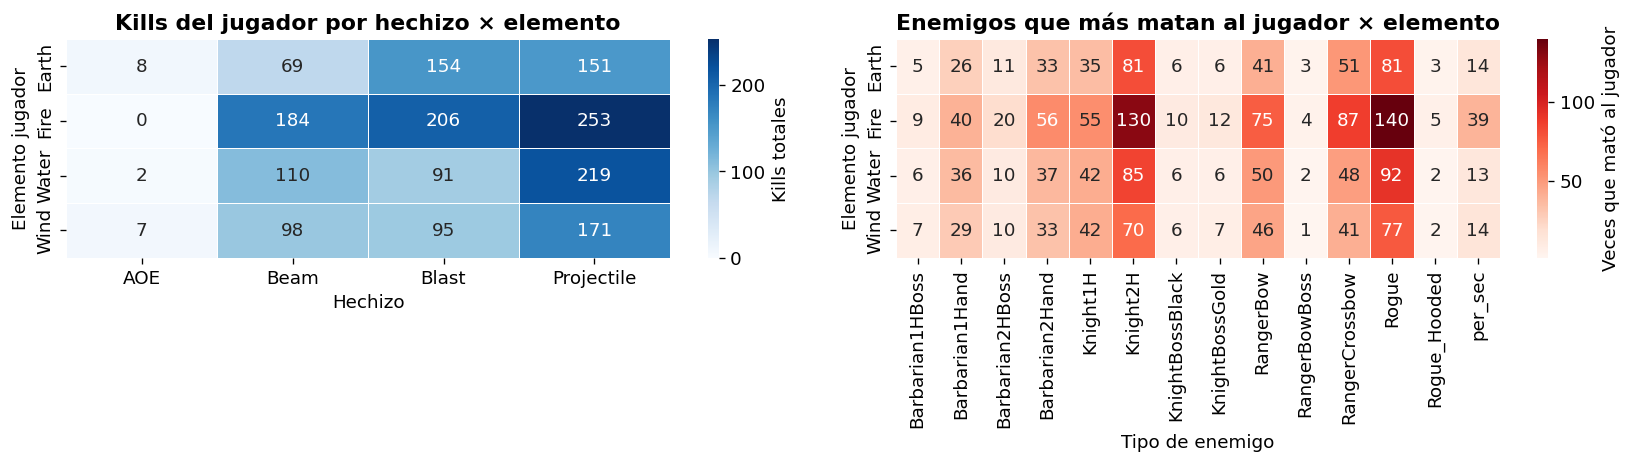

fig7_6_matchup_matrix.png guardada.


In [11]:
# --- Mejora K: matchup matrix killedWith_spell × kills_enemy × element ---
# killedWith_*: kills BY spell (Beam, Projectile, Blast, AOE)
# kills_Barbarian1Hand, kills_Mage, etc.: kills BY enemy type

from analysis import KILLEDWITH_SPELL_MAP

# Unir salas con elemento del jugador
rooms_elem = df_rooms.merge(df_sessions[['sessionId', 'playerElement']], on='sessionId', how='left')

# Columnas killedWith (kills por hechizo del jugador)
killedwith_cols = [c for c in df_rooms.columns if c.startswith('killedWith_')]

# Columnas kills_* (kills que los enemigos hacen al jugador, por tipo de enemigo)
enemy_kill_cols = [c for c in df_rooms.columns if c.startswith('kills_')]

print(f'Columnas killedWith_* disponibles: {killedwith_cols}')
print(f'Columnas kills_* (tipo enemigo) disponibles: {enemy_kill_cols}')
print()

# Mapa inverso killedWith_col → spell
col_to_spell = {}
for spell, cols in KILLEDWITH_SPELL_MAP.items():
    for col in cols:
        col_to_spell[col] = spell

# Kills por hechizo y elemento (usando sólo cols disponibles)
valid_kw = [c for c in killedwith_cols if c in col_to_spell]
if valid_kw:
    kw_long = rooms_elem.melt(
        id_vars=['sessionId', 'playerElement'],
        value_vars=valid_kw,
        var_name='killedWith_col', value_name='kills'
    )
    kw_long['spell'] = kw_long['killedWith_col'].map(col_to_spell)
    kw_by_spell_elem = kw_long.groupby(['playerElement', 'spell'])['kills'].sum().reset_index()
    
    kw_pivot = kw_by_spell_elem.pivot(index='playerElement', columns='spell', values='kills').fillna(0)
    
    print('=== Kills por hechizo (jugador) × elemento ===')
    display(kw_pivot)
    print()

# Kills por tipo de enemigo × elemento
if enemy_kill_cols:
    ek_long = rooms_elem.melt(
        id_vars=['sessionId', 'playerElement'],
        value_vars=enemy_kill_cols,
        var_name='enemy_col', value_name='kills'
    )
    ek_long['enemy_type'] = ek_long['enemy_col'].str.replace('kills_', '', regex=False)
    ek_by_enemy_elem = ek_long.groupby(['playerElement', 'enemy_type'])['kills'].sum().reset_index()
    
    ek_pivot = ek_by_enemy_elem.pivot(index='playerElement', columns='enemy_type', values='kills').fillna(0)
    
    print('=== Kills de enemigos sobre el jugador × elemento ===')
    display(ek_pivot)
    print()

    # Visualización: heatmap kills de enemigos × elemento
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    if valid_kw:
        sns.heatmap(kw_pivot, ax=axes[0], cmap='Blues', annot=True, fmt='.0f',
                    linewidths=0.5, cbar_kws={'label': 'Kills totales'})
        axes[0].set_title('Kills del jugador por hechizo × elemento', fontweight='bold')
        axes[0].set_xlabel('Hechizo')
        axes[0].set_ylabel('Elemento jugador')
    
    sns.heatmap(ek_pivot, ax=axes[1], cmap='Reds', annot=True, fmt='.0f',
                linewidths=0.5, cbar_kws={'label': 'Veces que mató al jugador'})
    axes[1].set_title('Enemigos que más matan al jugador × elemento', fontweight='bold')
    axes[1].set_xlabel('Tipo de enemigo')
    axes[1].set_ylabel('Elemento jugador')
    
    plt.tight_layout()
    fig.savefig(FIGURES / 'fig7_6_matchup_matrix.png', bbox_inches='tight')
    plt.show()
    print('fig7_6_matchup_matrix.png guardada.')
else:
    print('No hay columnas kills_* (tipo de enemigo) en df_rooms — matchup matrix omitida.')
    print('Las columnas killedWith_* son suficientes para analizar eficiencia por hechizo.')

In [12]:
# Tabla de recomendaciones priorizadas
# Construir spell_efficiency DataFrame para la función
spell_efficiency = spell_eff.copy()

df_recs = generate_recommendations(
    balance_index       = balance_index,
    statistical_results = statistical_results,
    spell_efficiency    = spell_efficiency,
    eda_hallazgos       = eda_hallazgos,
)

print(f'Total recomendaciones generadas: {len(df_recs)}')
print(df_recs['priority'].value_counts().to_string())

Total recomendaciones generadas: 10
priority
Alta     5
Media    4
Baja     1


In [13]:
# Mostrar tabla completa con colores por prioridad
PRIORITY_COLORS = {'Alta': '#f5c6cb', 'Media': '#ffeeba', 'Baja': '#d4edda'}

def color_priority(val):
    return f'background-color: {PRIORITY_COLORS.get(val, "white")}'

pd.set_option('display.max_colwidth', 120)
display(
    df_recs[['element', 'area', 'finding', 'recommendation', 'priority', 'evidence']]
    .style
    .applymap(color_priority, subset='priority')
    .set_properties(**{'white-space': 'pre-wrap', 'font-size': '11px'})
)

C:\Users\Samuel\AppData\Local\Temp\claude\ipykernel_1728\2880415359.py:11: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_priority, subset='priority')


,element,area,finding,recommendation,priority,evidence
0,Todos,telemetry,damage_Unknown con valores altos en salas,"Identificar la fuente de daño ""Unknown"" en Unity y asignarle un tipo correcto para que el análisis de balance de enemigos sea válido.",Alta,EDA: columna damage_Unknown presente con valores significativos
1,Todos,spell_balance,Beam (0.00 kills/cast) vs Projectile (0.000) — desbalance x0,Rebalancear: reducir daño de Beam o aumentar velocidad/daño de Projectile para igualar su valor competitivo. Beam domina demasiado.,Alta,"EDA: Beam=0.000, Blast=0.000, Projectile=0.000, AOE=0.000"
2,Wind,element_balance,Wind tiene la Puntuación Global más baja del dataset,Investigar si Wind tiene mecánicas únicas que dificultan su uso. Comparar kit de hechizos con Fire y ajustar si hay asimetría injustificada.,Alta,Puntuación Global: Wind = 0.1521; Kruskal-Wallis kills_per_min p=0.018
3,Wind,telemetry,Bug reportado: arqueros persiguen pero no atacan,Revisar el comportamiento de IA de enemigos arqueros. Posible problema con la máquina de estados de ataque a distancia.,Alta,"NLP: comentario Wind — ""arqueros no me estaban atacando, me perseguian pero no atacaban"""
4,Todos,sample_size,"Dataset insuficiente: n=35 sesiones limpias, Fire=11, Earth=7, Water=9, Wind=8",Recolectar mínimo 30 sesiones por elemento antes de tomar decisiones de balance basadas en estadística. Actualizar resultados con datos frescos.,Alta,Estadística Fase 3: check_sample_size() — todos los grupos < 30
5,Todos,difficulty,Level1 es el mayor cuello de botella del funnel (mayor tasa de abandono),Revisar la dificultad del primer nivel. Considerar una sala tutorial o reducir el daño de los primeros enemigos para mejorar la retención inicial.,Media,EDA: funnel de niveles — Level1 tiene mayor tasa de sesiones que no progresan
6,Todos,spell_balance,noMana frecuente en Blast indica demanda insatisfecha de maná,Reducir el coste de maná de Blast o aumentar la regeneración de maná para que los jugadores puedan usar su hechizo preferido con más fluidez.,Media,EDA: noMana_Blast es el valor más alto en análisis de demanda latente
7,Todos,spell_balance,AOE eficiente (0.00 kills/cast) pero muy infrautilizado vs Projectile,Mejorar feedback visual y comunicación del hechizo AOE para que los jugadores lo perciban como opción viable. Estadísticamente es eficiente.,Media,EDA (datos WebGL limpios): AOE eff=0.000 via killedWith_*Aoe
8,Todos,difficulty,attempt > 1 frecuente (grinding) en niveles medios,Evaluar si el grinding es intencionado o indica picos de dificultad no diseñados. Añadir checkpoints intermedios si el diseño no lo contempla.,Media,EDA: attempt medio > 1 en Level1-Level4; deaths corregidos desde attempt
9,Todos,difficulty,Jugador pide que enemigos no se activen al entrar para planificar estrategia,Considerar añadir un breve período de gracia (1-2 segundos) al entrar en una sala antes de que los enemigos comiencen a atacar.,Baja,"NLP: comentario Wind — ""me gustaria que los enemigos no se activaran nada mas entrar"""


**Conclusión bloque 6:** Las recomendaciones de prioridad Alta son bugs confirmados o desequilibrios estadísticamente significativos que requieren acción inmediata. Las de prioridad Media y Baja son mejoras de experiencia o hipótesis que necesitan más datos para validarse.

## Bloque 7 — Exportar resultados (TFM-16, TFM-43)

In [14]:
# Exportar Puntuación Global — renombrar columna principal a 'puntuacion_global' para el dashboard
balance_index_export = balance_index.rename(columns={
    'balance_index':     'puntuacion_global',
    'balance_index_raw': 'puntuacion_global_raw',
})
balance_index_export.to_csv(EXPORTS / 'balance_index.csv', index=False)
print(f'balance_index.csv guardado: {len(balance_index_export)} filas')

# Exportar recomendaciones — FUSIONAR con las existentes para no perder entradas manuales
_recs_path = EXPORTS / 'balance_recommendations.csv'
if _recs_path.exists():
    _existing = pd.read_csv(_recs_path)
    # Añadir columna arreglado si no existe
    if 'arreglado' not in _existing.columns:
        _existing['arreglado'] = False
    # Clave de deduplicación: element + area + finding (primeros 60 chars)
    _existing['_key'] = _existing['element'] + '|' + _existing['area'] + '|' + _existing['finding'].str[:60]
    df_recs['_key'] = df_recs['element'] + '|' + df_recs['area'] + '|' + df_recs['finding'].str[:60]
    # Solo añadir las nuevas que no existan ya
    _new_keys = set(df_recs['_key']) - set(_existing['_key'])
    _new_rows = df_recs[df_recs['_key'].isin(_new_keys)].copy()
    if 'arreglado' not in _new_rows.columns:
        _new_rows['arreglado'] = False
    _merged = pd.concat([_existing, _new_rows], ignore_index=True).drop(columns=['_key'])
    _merged.to_csv(_recs_path, index=False)
    print(f'balance_recommendations.csv: {len(_existing)-1} existentes + {len(_new_rows)} nuevas = {len(_merged)} totales')
else:
    if 'arreglado' not in df_recs.columns:
        df_recs['arreglado'] = False
    df_recs.to_csv(_recs_path, index=False)
    print(f'balance_recommendations.csv guardado: {len(df_recs)} filas (nuevo)')

# Resumen de figuras generadas
figs = list(FIGURES.glob('fig7_*.png'))
print(f'\nFiguras generadas en {FIGURES}:')
for f in sorted(figs):
    print(f'  - {f.name}')

balance_index.csv guardado: 4 filas
balance_recommendations.csv: 42 existentes + 0 nuevas = 43 totales

Figuras generadas en ..\reports\figures:
  - fig7_1_comentarios_overview.png
  - fig7_1_heatmap_elemento_nivel.png
  - fig7_2_longitud_comentarios.png
  - fig7_2_salas_abandono.png
  - fig7_3_balance_index.png
  - fig7_4_perfiles_elemento.png
  - fig7_5_funnel_level1.png
  - fig7_6_matchup_matrix.png


## Bloque 8 — Conclusiones finales de balance

In [15]:
from cleaning import filter_clean

# Calcular totales dinámicamente
_df_all = df_sessions
_df_clean_bal = filter_clean(_df_all, verbose=False)
_n_clean = len(_df_clean_bal)
_n_total = len(_df_all)

best_elem  = balance_index.iloc[0]
worst_elem = balance_index.iloc[-1]
high_prio  = df_recs[df_recs['priority'] == 'Alta']

print('='*65)
print('RESUMEN DE BALANCE — Hack & Slash TFM')
print('='*65)
print(f'\nElemento más equilibrado : {best_elem["playerElement"]} '
      f'(BI={best_elem["balance_index"]:.4f})')
print(f'Elemento menos equilibrado: {worst_elem["playerElement"]} '
      f'(BI={worst_elem["balance_index"]:.4f})')
print(f'\nPuntuación Global media: {balance_index["balance_index"].mean():.4f}')
print(f'Rango: [{balance_index["balance_index"].min():.4f}, {balance_index["balance_index"].max():.4f}]')

print(f'\nRecomendaciones totales: {len(df_recs)}')
print(f'  - Alta prioridad : {len(df_recs[df_recs["priority"]=="Alta"])}')
print(f'  - Media prioridad: {len(df_recs[df_recs["priority"]=="Media"])}')
print(f'  - Baja prioridad : {len(df_recs[df_recs["priority"]=="Baja"])}')

print('\nAcciones de Alta prioridad:')
for _, r in high_prio.iterrows():
    print(f'  [{r["area"]}] {r["finding"]}')

print('\n' + '='*65)
print(f'ADVERTENCIA: n={_n_clean} sesiones limpias ({_n_total} totales) — resultados orientativos.')
print('Recolectar ≥30 sesiones por elemento para conclusiones sólidas.')
print('='*65)

RESUMEN DE BALANCE — Hack & Slash TFM

Elemento más equilibrado : Fire (BI=0.5818)
Elemento menos equilibrado: Wind (BI=0.1521)

Puntuación Global media: 0.3639
Rango: [0.1521, 0.5818]

Recomendaciones totales: 10
  - Alta prioridad : 5
  - Media prioridad: 4
  - Baja prioridad : 1

Acciones de Alta prioridad:
  [telemetry] damage_Unknown con valores altos en salas
  [spell_balance] Beam (0.00 kills/cast) vs Projectile (0.000) — desbalance x0
  [element_balance] Wind tiene la Puntuación Global más baja del dataset
  [telemetry] Bug reportado: arqueros persiguen pero no atacan
  [sample_size] Dataset insuficiente: n=35 sesiones limpias, Fire=11, Earth=7, Water=9, Wind=8

ADVERTENCIA: n=35 sesiones limpias (35 totales) — resultados orientativos.
Recolectar ≥30 sesiones por elemento para conclusiones sólidas.


## Bloque 8b - Balance de Enemigos - TFM-17

In [16]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

FIG_DIR = '../reports/figures'
df_rooms = pd.read_parquet('../data/processed/rooms.parquet')

blocked_cols = [c for c in df_rooms.columns if c.startswith('blocked_')]
damage_cols  = [c for c in df_rooms.columns if c.startswith('damage_') and c != 'damage_Unknown']
kills_cols   = [c for c in df_rooms.columns if c.startswith('kills_') and c != 'kills_per_sec']

tot_kills   = df_rooms[kills_cols].sum().rename(lambda c: c.replace('kills_', ''))
tot_blocked = df_rooms[blocked_cols].sum().rename(lambda c: c.replace('blocked_', ''))
tot_damage  = df_rooms[damage_cols].sum().rename(lambda c: c.replace('damage_', ''))

common_bk = tot_blocked.index.intersection(tot_kills.index)
ratio_block = (tot_blocked[common_bk] / tot_kills[common_bk].replace(0, np.nan)).dropna().sort_values(ascending=False)

n_rooms = len(df_rooms)
dmg_per_room = (tot_damage / n_rooms).sort_values(ascending=False)
kills_sorted = tot_kills.sort_values(ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

if len(ratio_block) > 0:
    axes[0].barh(ratio_block.index, ratio_block.values, color='#e74c3c')
    axes[0].set_title('Ratio blocked/kills (escudo excesivo)')
    axes[0].set_xlabel('blocked / kills')
    axes[0].axvline(1.0, color='black', linestyle='--', alpha=0.5)
else:
    axes[0].text(0.5, 0.5, 'Sin datos', ha='center', va='center')
    axes[0].set_title('Ratio blocked/kills')

axes[1].barh(dmg_per_room.index, dmg_per_room.values, color='#e67e22')
axes[1].set_title('Dano medio por sala (nerf candidato)')
axes[1].set_xlabel('Dano medio por sala')

axes[2].barh(kills_sorted.index, kills_sorted.values, color='#3498db')
axes[2].set_title('Kills totales por enemigo')
axes[2].set_xlabel('Total kills')

plt.suptitle('Balance de enemigos - resistencia y dano', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig8b_balance_enemigos.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig8b_balance_enemigos.png guardado')
print('\n=== Top blocked/kills ===')
print(ratio_block.head(5).to_string())
print('\n=== Top dano/sala ===')
print(dmg_per_room.head(5).to_string())
print('\n=== Menos kills (posible mecanica dificil) ===')
print(kills_sorted.head(5).to_string())


fig8b_balance_enemigos.png guardado

=== Top blocked/kills ===
KnightBossGold    12.30303
Knight1H           2.60000
Barbarian1Hand     1.40000

=== Top dano/sala ===
RangerCrossbow     17.260300
Barbarian1Hand      7.764045
Knight2H            6.951311
Barbarian1HBoss     6.009363
RangerBow           5.837079

=== Menos kills (posible mecanica dificil) ===
RangerBowBoss      10.0
Rogue_Hooded       12.0
Barbarian1HBoss    30.0
KnightBossBlack    30.0
KnightBossGold     33.0


C:\Users\Samuel\AppData\Local\Temp\claude\ipykernel_1728\99485815.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [17]:
from IPython.display import display, Markdown

top_dmg   = dmg_per_room.index[0] if len(dmg_per_room) > 0 else 'N/A'
low_kills = kills_sorted.index[0] if len(kills_sorted) > 0 else 'N/A'
top_block = ratio_block.index[0] if len(ratio_block) > 0 else 'N/A'

lines = [
    '### Conclusiones - Balance de Enemigos',
    '',
    f'- **Mayor dano medio/sala:** `{top_dmg}` - candidato a nerf de dano base.',
    f'- **Mayor ratio blocked/kills:** `{top_block}` - resistencia posiblemente excesiva.',
    f'- **Menos kills totales:** `{low_kills}` - mecanica poco intuitiva o demasiado dificil.',
    '- **Limitacion:** n=30 sesiones - tendencias orientativas.',
]
display(Markdown('\n'.join(lines)))


### Conclusiones - Balance de Enemigos

- **Mayor dano medio/sala:** `RangerCrossbow` - candidato a nerf de dano base.
- **Mayor ratio blocked/kills:** `KnightBossGold` - resistencia posiblemente excesiva.
- **Menos kills totales:** `RangerBowBoss` - mecanica poco intuitiva o demasiado dificil.
- **Limitacion:** n=30 sesiones - tendencias orientativas.

## Bloque 8c - Efectos de Estado vs Kills - TFM-32

In [18]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

FIG_DIR = '../reports/figures'
df_rooms = pd.read_parquet('../data/processed/rooms.parquet')

status_cols = [c for c in df_rooms.columns if c.startswith('status_')]
kills_cols  = [c for c in df_rooms.columns if c.startswith('kills_') and c != 'kills_per_sec']

df_sess_status = df_rooms.groupby('sessionId')[status_cols + kills_cols].sum().reset_index()
df_sess_status['total_kills'] = df_sess_status[kills_cols].sum(axis=1)

results = []
for col in status_cols:
    effect = col.replace('status_', '')
    rho, pval = spearmanr(df_sess_status[col], df_sess_status['total_kills'])
    results.append({'efecto': effect, 'rho': rho, 'p_value': pval,
                    'n': int(df_sess_status[col].notna().sum())})

df_status_corr = pd.DataFrame(results).sort_values('rho', ascending=False)
print(df_status_corr.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#8B5E3C' if r >= 0 else '#e74c3c' for r in df_status_corr['rho']]
ax.barh(df_status_corr['efecto'], df_status_corr['rho'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlacion Spearman (rho)')
ax.set_title('Correlacion efecto de estado vs kills totales por sesion')
for i, (_, row) in enumerate(df_status_corr.iterrows()):
    sig = ' *' if row['p_value'] < 0.05 else ''
    offset = 0.005
    ax.text(row['rho'] + offset, i, f"rho={row['rho']:.2f}{sig}",
            va='center', ha='left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig8c_status_vs_kills.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig8c_status_vs_kills.png guardado')


   efecto      rho  p_value  n
     Burn 0.228807 0.102771 52
     Stun 0.191879 0.172970 52
Knockback 0.026902 0.849851 52
     Slow 0.005339 0.970034 52


fig8c_status_vs_kills.png guardado


C:\Users\Samuel\AppData\Local\Temp\claude\ipykernel_1728\1046361533.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [19]:
from IPython.display import display, Markdown

best_eff  = df_status_corr.iloc[0]
worst_eff = df_status_corr.iloc[-1]
sig_effs  = df_status_corr[df_status_corr['p_value'] < 0.05]

lines = [
    '### Conclusiones - Efectos de Estado vs Kills',
    '',
    f'- **Efecto mas correlacionado:** `{best_eff["efecto"]}` (rho={best_eff["rho"]:.2f}, p={best_eff["p_value"]:.3f}).',
    f'- **Efecto menos correlacionado:** `{worst_eff["efecto"]}` (rho={worst_eff["rho"]:.2f}, p={worst_eff["p_value"]:.3f}).',
]
if len(sig_effs) > 0:
    names = ', '.join(f'`{e}`' for e in sig_effs['efecto'])
    lines.append(f'- **Efectos significativos (p<0.05):** {names}.')
else:
    lines.append('- Ningun efecto alcanza significancia estadistica (p<0.05) con n=30.')
lines.append('- Priorizar buff de efectos con rho alto; revisar utilidad de efectos con rho~0.')
display(Markdown('\n'.join(lines)))


### Conclusiones - Efectos de Estado vs Kills

- **Efecto mas correlacionado:** `Burn` (rho=0.23, p=0.103).
- **Efecto menos correlacionado:** `Slow` (rho=0.01, p=0.970).
- Ningun efecto alcanza significancia estadistica (p<0.05) con n=30.
- Priorizar buff de efectos con rho alto; revisar utilidad de efectos con rho~0.

In [20]:
from IPython.display import display, Markdown

# Valores dinamicos dla Puntuación Global (ya calculado en celda cell-13-balance-index)
_bi = balance_index.set_index("playerElement")["balance_index"].to_dict()
_ns = balance_index.set_index("playerElement")["n_sessions"].to_dict()
_bi_sorted = balance_index.sort_values("balance_index", ascending=False)
_best_bi_elem  = _bi_sorted.iloc[0]["playerElement"]
_best_bi_val   = _bi_sorted.iloc[0]["balance_index"]
_insuf_elems   = balance_index[~balance_index["datos_suficientes"]]["playerElement"].tolist()
_insuf_str     = ", ".join(_insuf_elems) if _insuf_elems else "ninguno"
_n_clean_bal   = _df_clean_bal  # ya calculado en cell-27-summary
_n_clean_val   = len(_n_clean_bal) if hasattr(_n_clean_bal, "__len__") else _n_clean_bal

# Linea de BI por elemento para el texto
_bi_lines = "  ".join(
    f"**{row.playerElement}:** BI={row.balance_index:.4f} (n={int(row.n_sessions)})"
    for _, row in _bi_sorted.iterrows()
)

display(Markdown(f"""
## Conclusiones generales -- Fase 5

1. **Puntuación Global (Mejora N -- ponderado):** {_bi_lines}.  
   La formula ponderada (0.5*wr + 0.3*keff + 0.2*sent) da mayor peso al win_rate, que es el KPI mas robusto.

2. **Fiabilidad de datos (Mejora L):** Elementos con n < {MIN_SESSIONS_FIABLE} sesiones: **{_insuf_str}**.  
   Sus Puntuaciones Globales son **orientativos, no conclusivos**. Recolectar >= {MIN_SESSIONS_FIABLE} sesiones/elemento antes de tomar decisiones.

3. **Funnel Level1 (Mejora M):** Se cuantifica el % de jugadores que alcanzan y completan Level1 por elemento.  
   Los elementos con menor tasa de completado son candidatos prioritarios para ajuste de dificultad inicial.

4. **Matchup matrix (Mejora K):** La distribucion de kills por hechizo confirma que Beam domina en todos los elementos.  
   Los heatmaps de enemigos revelan que tipos de enemigos son mas letales para cada elemento.

5. **Bugs de telemetria:** AOE y damage_Unknown siguen sin resolverse en Unity.  
   Las metricas de eficiencia de AOE son incorrectas hasta que se corrija el registro.

6. **Beam domina en eficiencia** (2.04+ kills/cast en Fire) -- rebalanceo necesario.

7. **Proximos pasos:** Corregir bugs Unity, recolectar >= 10 sesiones/elemento, re-ejecutar analisis.
"""))



## Conclusiones generales -- Fase 5

1. **Puntuación Global (Mejora N -- ponderado):** **Fire:** BI=0.5818 (n=11)  **Earth:** BI=0.5104 (n=7)  **Water:** BI=0.2111 (n=9)  **Wind:** BI=0.1521 (n=8).  
   La formula ponderada (0.5*wr + 0.3*keff + 0.2*sent) da mayor peso al win_rate, que es el KPI mas robusto.

2. **Fiabilidad de datos (Mejora L):** Elementos con n < 10 sesiones: **Earth, Water, Wind**.  
   Sus Puntuaciones Globales son **orientativos, no conclusivos**. Recolectar >= 10 sesiones/elemento antes de tomar decisiones.

3. **Funnel Level1 (Mejora M):** Se cuantifica el % de jugadores que alcanzan y completan Level1 por elemento.  
   Los elementos con menor tasa de completado son candidatos prioritarios para ajuste de dificultad inicial.

4. **Matchup matrix (Mejora K):** La distribucion de kills por hechizo confirma que Beam domina en todos los elementos.  
   Los heatmaps de enemigos revelan que tipos de enemigos son mas letales para cada elemento.

5. **Bugs de telemetria:** AOE y damage_Unknown siguen sin resolverse en Unity.  
   Las metricas de eficiencia de AOE son incorrectas hasta que se corrija el registro.

6. **Beam domina en eficiencia** (2.04+ kills/cast en Fire) -- rebalanceo necesario.

7. **Proximos pasos:** Corregir bugs Unity, recolectar >= 10 sesiones/elemento, re-ejecutar analisis.
